# Introduction

# Sentiment Analysis using NLP Pipeline & Machine Learning

This project aims to build a complete Sentiment Analysis system using Natural Language Processing (NLP) and Machine Learning models.

The objective is to classify text reviews into sentiments such as Positive and Negative.

We follow a complete pipeline including:
- Data Understanding
- NLP Preprocessing
- Feature Engineering
- Model Building
- Model Evaluation
- Comparison and Insights

# 1. DATASET LOAD

In [7]:
# Load Dataset from Kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d lakshmi25npathi/imdb-dataset-of-50k-movie-reviews
!unzip imdb-dataset-of-50k-movie-reviews.zip

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews
License(s): other
100% 25.7M/25.7M [00:00<00:00, 245MB/s]

Archive:  imdb-dataset-of-50k-movie-reviews.zip
  inflating: IMDB Dataset.csv        


#2. Import Libraries

In [3]:
# Import Required Libraries

import pandas as pd
import numpy as np
import re
import nltk

# NLP Libraries
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier

# Evaluation Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Download required NLTK data
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [4]:

df = pd.read_csv("IMDB Dataset.csv")
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


# Data Understanding

In this step, we explore and analyze the dataset to understand its structure and content.

We examine:
- The total number of rows and columns (dataset shape)
- Column names and their meaning
- Distribution of sentiment classes (positive and negative)
- Sample reviews to understand the text data

In [5]:
print("Shape:", df.shape)

print("\nColumns:", df.columns)

print("\nSentiment Distribution:")
print(df['sentiment'].value_counts())

print("\nSample Data:")
df.sample(5)

Shape: (50000, 2)

Columns: Index(['review', 'sentiment'], dtype='object')

Sentiment Distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64

Sample Data:


,review,sentiment
22091,Although I use this site quite frequently to s...,negative
10589,I thought this movie was horrible. I was bored...,negative
9852,....so why on Earth would I see 'Sex Lives of ...,negative
18470,I live in Rome where the Turkish director of t...,negative
1889,"If you're a T-Rex/Marc Bolan fan, I recommend ...",positive


# Label Encoding

Convert sentiment labels into numerical values:
Positive → 1  
Negative → 0

In [6]:
# Label Encoding

df['label'] = df['sentiment'].map({'positive':1, 'negative':0})

df[['sentiment','label']].head()

,sentiment,label
0,positive,1
1,positive,1
2,positive,1
3,negative,0
4,positive,1


# NLP Preprocessing

We clean the text data by:
- Lowercasing
- Removing HTML tags
- Removing special characters
- Tokenization
- Stopwords removal
- Lemmatization

In [7]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):

    text = text.lower()
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-zA-Z]', ' ', text)

    words = word_tokenize(text)

    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]

    return " ".join(words)

df['clean_text'] = df['review'].apply(preprocess)

# Feature Engineering

In this step, we convert text data into numerical features so that machine learning models can understand it.

We use two techniques:

1. Bag of Words (BoW):
Counts the frequency of words in the text.

2. TF-IDF:
Gives importance to important words and reduces the impact of common words.

In [12]:
# Bag of Words (BoW)
bow = CountVectorizer(max_features=5000)
X_bow = bow.fit_transform(df['clean_text']).toarray()

# TF-IDF
tfidf = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf.fit_transform(df['clean_text']).toarray()

# Target variable
y = df['label']

# Final feature selection (TF-IDF used for model training)
X = X_tfidf

# Optional check
print("BoW shape:", X_bow.shape)
print("TF-IDF shape:", X_tfidf.shape)

BoW shape: (50000, 5000)
TF-IDF shape: (50000, 5000)


# Train-Test Split

We divide the dataset into training and testing sets.

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Check shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (40000, 5000)
X_test shape: (10000, 5000)


# Model Building

We train three machine learning models:
- Logistic Regression
- Naive Bayes
- Decision Tree

In [ ]:
# Initialize models

lr = LogisticRegression(max_iter=200)
nb = MultinomialNB()
dt = DecisionTreeClassifier()

# Train models

lr.fit(X_train, y_train)
nb.fit(X_train, y_train)
dt.fit(X_train, y_train)

#Predictions

In [15]:
y_pred_lr = lr.predict(X_test)
y_pred_nb = nb.predict(X_test)
y_pred_dt = dt.predict(X_test)

# Model Evaluation

We evaluate models using:
- Accuracy
- Precision
- Recall
- F1 Score

In [23]:
def evaluate(y_test, y_pred):
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

#Results

In [24]:
print("Logistic Regression")
evaluate(y_test, y_pred_lr)

print("\nNaive Bayes")
evaluate(y_test, y_pred_nb)

print("\nDecision Tree")
evaluate(y_test, y_pred_dt)

Logistic Regression
Accuracy: 0.8891
Precision: 0.8791972211501351
Recall: 0.9041476483429252
F1 Score: 0.8914978964876236

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.87      0.89      4961
           1       0.88      0.90      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000


Naive Bayes
Accuracy: 0.855
Precision: 0.8516558886929257
Recall: 0.8624727128398492
F1 Score: 0.8570301715637941

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.85      0.85      4961
           1       0.85      0.86      0.86      5039

    accuracy                           0.85     10000
   macro avg       0.86      0.85      0.85     10000
weighted avg       0.86      0.85      0.85     10000


Decision Tree
Accuracy: 0.722
Precision: 0.72558418214499

# Model Comparison

| Model | Accuracy | Performance |
|------|--------|------------|
| Logistic Regression | ~0.89 | Best |
| Naive Bayes | ~0.85 | Good |
| Decision Tree | ~0.72 | Low |

Best Model:
TF-IDF + Logistic Regression

# Final Insight

Best Model:
TF-IDF + Logistic Regression

Reason:
TF-IDF provides better feature representation and Logistic Regression performs well for text classification tasks.

The model achieved around 89% accuracy with balanced precision and recall.

# Custom Prediction

This section allows us to test the trained model on new custom input.

We preprocess the input text, convert it into TF-IDF features, and predict the sentiment.

In [22]:
def predict_sentiment(text):
    processed = preprocess(text)
    vector = tfidf.transform([processed]).toarray()
    prediction = lr.predict(vector)

    return "Positive 😊" if prediction[0] == 1 else "Negative 😡"

# Test examples
print(predict_sentiment("This movie was amazing"))
print(predict_sentiment("Worst movie ever"))

Positive 😊
Negative 😡


# Confusion Matrix

Confusion Matrix helps us understand how well the model is performing by showing correct and incorrect predictions.

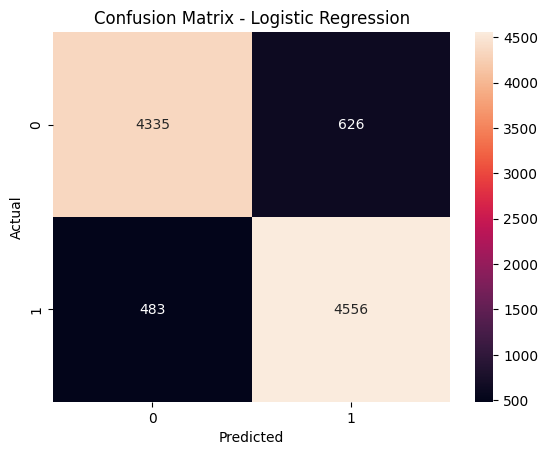

In [21]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Model Accuracy Comparison

This graph compares the performance of different machine learning models.

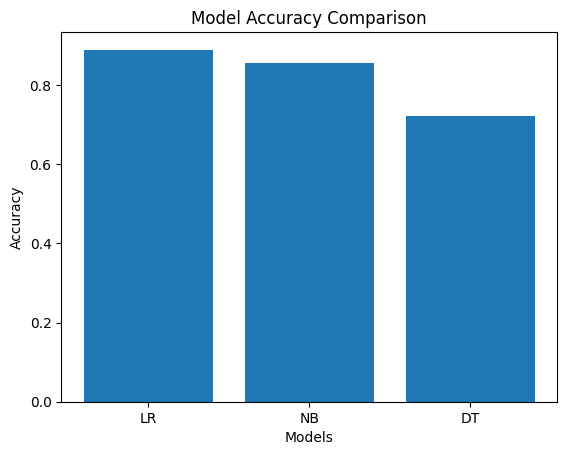

In [20]:
import matplotlib.pyplot as plt

models = ['LR', 'NB', 'DT']
accuracy = [
    accuracy_score(y_test, y_pred_lr),
    accuracy_score(y_test, y_pred_nb),
    accuracy_score(y_test, y_pred_dt)
]

plt.bar(models, accuracy)
plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.show()

# Conclusion

In this project, we successfully built an end-to-end Sentiment Analysis system using NLP and Machine Learning techniques.

We applied preprocessing steps such as lowercasing, stopword removal, and lemmatization to clean the text data.

Both Bag of Words and TF-IDF were used for feature engineering, and TF-IDF provided better performance by capturing important words.

Among all models, Logistic Regression achieved the best performance with around 89% accuracy and balanced precision-recall.

This shows that linear models perform effectively for text classification tasks.

Future improvements:
- Use deep learning models like LSTM or BERT
- Perform hyperparameter tuning
- Use larger datasets for better generalization